In [1]:
%pip install pandas scikit-learn seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


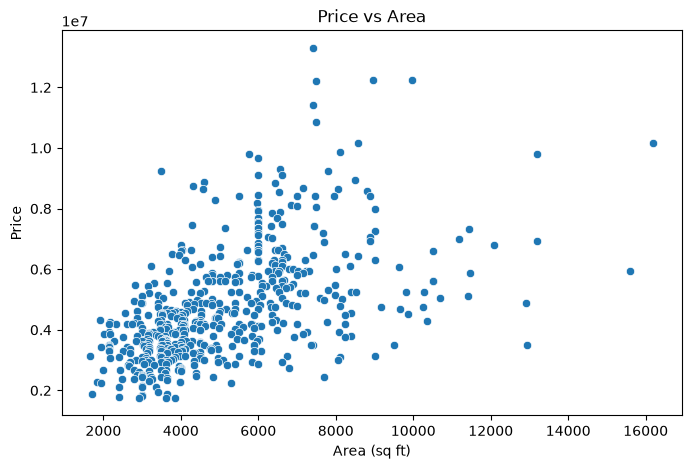

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='area', y='price', data=df)
plt.title("Price vs Area")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.show()

In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [10]:
from sklearn.preprocessing import LabelEncoder

# Create separate encoders
le_mainroad = LabelEncoder()
le_guestroom = LabelEncoder()
le_basement = LabelEncoder()
le_hotwaterheating = LabelEncoder()
le_airconditioning = LabelEncoder()
le_prefarea = LabelEncoder()
le_furnishingstatus = LabelEncoder()

# Apply encoding
df["mainroad"] = le_mainroad.fit_transform(df["mainroad"])
df["guestroom"] = le_guestroom.fit_transform(df["guestroom"])
df["basement"] = le_basement.fit_transform(df["basement"])
df["hotwaterheating"] = le_hotwaterheating.fit_transform(df["hotwaterheating"])
df["airconditioning"] = le_airconditioning.fit_transform(df["airconditioning"])
df["prefarea"] = le_prefarea.fit_transform(df["prefarea"])
df["furnishingstatus"] = le_furnishingstatus.fit_transform(df["furnishingstatus"])

In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [12]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [13]:
print(df.corr()["price"].sort_values(ascending=False))

price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
furnishingstatus   -0.304721
Name: price, dtype: float64


Segregating the Input and Output Columns

In [14]:
# Features (all except 'price')
X = df.drop(["price"], axis=1)

# Target variable
y = df["price"]

Spliting it on 80/20 Rule

In [15]:
# Linear Regression for House Price Prediction
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Importing and Configuring Linear Regression Model

In [16]:
from sklearn.linear_model import LinearRegression

# Initialize and train model
model = LinearRegression()

Training

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 235.85, 78574.49,1097117.27,..., 225756.51, 629901.66,-210397.12]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['area','bedrooms','bathrooms',...,'parking','prefarea','furnishingstatus']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.931e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [18]:
# Predictions
y_pred = model.predict(X_test)

In [19]:
y_pred[0:10]

array([5203691.70963178, 7257004.02115476, 3062828.59668172,
       4559591.65374424, 3332932.30559782, 3563080.67918997,
       5645466.31219972, 6413979.66873635, 2755831.54819   ,
       2668938.66075229])

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)   # ✅ RMSE is often used in regression
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R^2 Score:", r2)
accuracy = r2 * 100
print(f"Accuracy: {accuracy:.2f}%")

Mean Absolute Error (MAE): 979679.6912959905
Mean Squared Error (MSE): 1771751116594.0347
Root Mean Squared Error (RMSE): 1331071.4167895105
R^2 Score: 0.6494754192267804
Accuracy: 64.95%


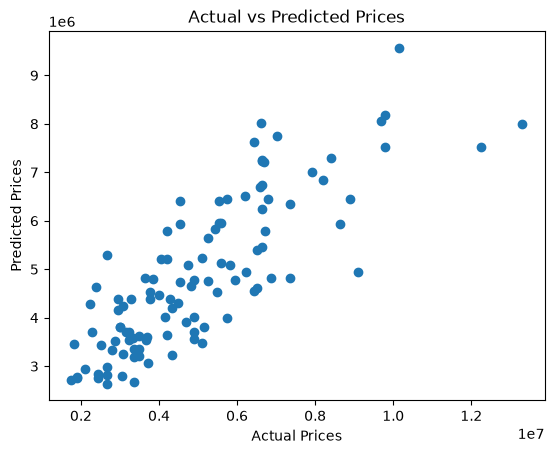

In [21]:
# Plot 
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

In [22]:
%pip install pypickle 

Note: you may need to restart the kernel to use updated packages.


In [23]:
# Saving model Pkl File
import pickle
with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [24]:
# Using this pickled model for prediction
with open("linear_regression_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [25]:
# 1. Naya Sample Data (Wahi columns jo aapne training mein use kiye)
sample_data = {
    "area": 3000,
    "bedrooms": 3,
    "bathrooms": 2,
    "stories": 2,
    "mainroad": 'yes',
    "guestroom": "no",
    "basement": "yes",
    "hotwaterheating": "no",
    "airconditioning": "yes",
    "parking": 2,
    "prefarea": "yes",
    "furnishingstatus": "furnished"
}

sample_df = pd.DataFrame([sample_data])

# 2. Aapke apne Label Encoders use karte huay Transform karein
sample_df["mainroad"] = le_mainroad.transform(sample_df["mainroad"])
sample_df["guestroom"] = le_guestroom.transform(sample_df["guestroom"])
sample_df["basement"] = le_basement.transform(sample_df["basement"])
sample_df["hotwaterheating"] = le_hotwaterheating.transform(sample_df["hotwaterheating"])
sample_df["airconditioning"] = le_airconditioning.transform(sample_df["airconditioning"])
sample_df["prefarea"] = le_prefarea.transform(sample_df["prefarea"])
sample_df["furnishingstatus"] = le_furnishingstatus.transform(sample_df["furnishingstatus"])


# 4. Final Prediction
prediction = model.predict(sample_df)

print(f"Ghar ki Predicted Price hai: {prediction[0]:,.2f}")

Ghar ki Predicted Price hai: 6,869,982.96


In [26]:
encoders = {
    "mainroad": le_mainroad,
    "guestroom": le_guestroom,
    "basement": le_basement,
    "hotwaterheating": le_hotwaterheating,
    "airconditioning": le_airconditioning,
    "prefarea": le_prefarea,
    "furnishingstatus": le_furnishingstatus,
}


with open("label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [27]:
with open("label_encoders.pkl", "rb") as f:
    encoders = pickle.load(f)